# Lab 9: Network Statistics

In prior labs, we measured the degree of a vertex (interchangable with a node) as a local property.
This is a useful metric for comparing degree sequences (which give hints to graph isomorphisms), but those sequences can grow long as the number of vertices $n$ grows, and only captures local interactions. We turn our attention to more global summaries of the entire graph; these global summaries help us compare large-scale networks based on their key metrics.

We will investigate:
- the average degree of a graph
- degree histograms and distributions
- how hubs influence a network
- how different graph models can have very different degree distributions.


In [1]:
from lab9_helpers import *
import networkx as nx

### Part 1: Degree as a local and global property

We begin with a small graph. First inspect individual degrees, then summarize the whole graph.

In [2]:
G = sample_graph()
graph_summary(G)

{'number_of_nodes': 8,
 'number_of_edges': 11,
 'nodes': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
 'edges': [('A', 'B'),
  ('A', 'C'),
  ('A', 'D'),
  ('B', 'C'),
  ('B', 'E'),
  ('C', 'F'),
  ('D', 'E'),
  ('D', 'F'),
  ('E', 'G'),
  ('F', 'H'),
  ('G', 'H')],
 'degree_dict': {'A': 3,
  'B': 3,
  'C': 3,
  'D': 3,
  'E': 3,
  'F': 3,
  'G': 2,
  'H': 2}}

In [3]:
degree_table(G)

[('A', 3),
 ('B', 3),
 ('C', 3),
 ('D', 3),
 ('E', 3),
 ('F', 3),
 ('G', 2),
 ('H', 2)]

In [4]:
degree_sequence(G)

[3, 3, 3, 3, 3, 3, 2, 2]

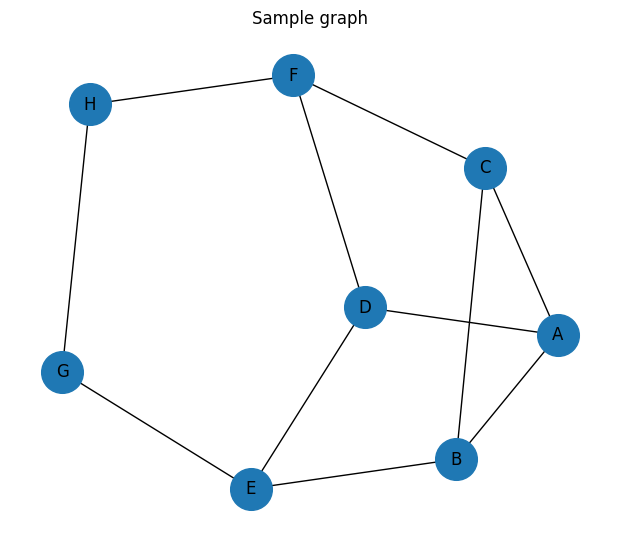

In [5]:
draw_graph(G, "Sample graph")

Questions:
- Which vertex has the largest degree?
- Which vertices have the smallest degree?
- Does the graph appear to have a hub?
- What does the degree sequence show that the drawing does not show immediately?

### Part 2: Degree histogram

A degree histogram shows how many vertices have degree 0, 1, 2, 3, and so on.

In [6]:
degree_histogram_data(G)

{2: 2, 3: 6}

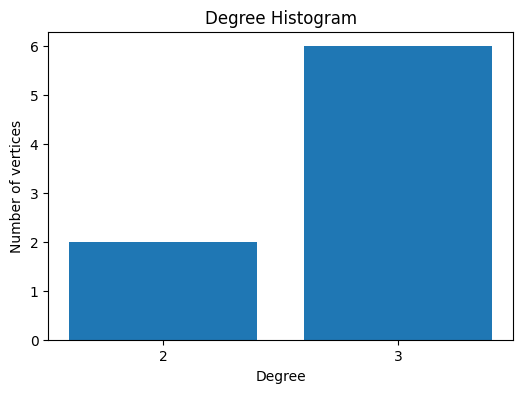

In [7]:
plot_degree_histogram(G)

### Part 3: What does the average degree hide?

The average degree is a useful summary, but it does not tell the whole story.

In [8]:
average_degree(G)

2.75

Questions:
- Does the average degree describe a “typical” vertex well?
- Can a graph have average degree near 2, but still contain a high-degree hub?
- What information is lost when we summarize a graph by one number?

### Part 4: Compare graphs with very different degree structure

Now compare a path graph, a cycle graph, and a star graph.

These are all simple graphs, but their degree distributions look very different.

In [9]:
P = path_graph(10)
C = cycle_graph(10)
S = star_graph(10)

In [11]:
print(f"Path degree sequence: {degree_sequence(P)}, path average degree: {average_degree(P)}") 
print(f"Cycle degree sequence: {degree_sequence(C)}, cycle average degree: {average_degree(C)}")
print(f"Star degree sequence: {degree_sequence(S)}, star average degree: {average_degree(S)}")  

Path degree sequence: [2, 2, 2, 2, 2, 2, 2, 2, 1, 1], path average degree: 1.8
Cycle degree sequence: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2], cycle average degree: 2.0
Star degree sequence: [9, 1, 1, 1, 1, 1, 1, 1, 1, 1], star average degree: 1.8


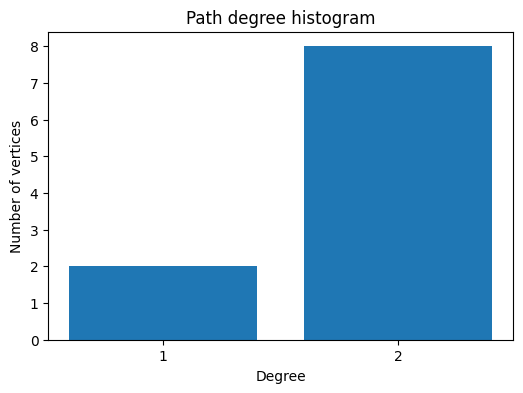

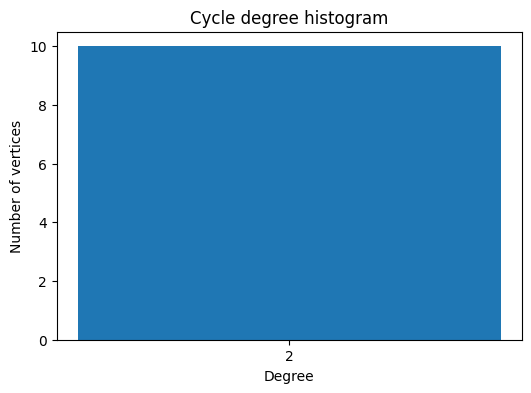

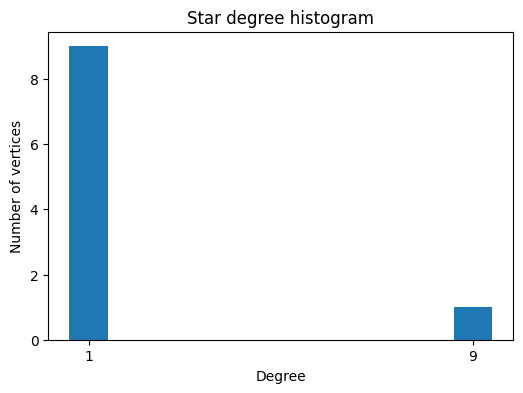

In [13]:
plot_degree_histogram(P, title='Path degree histogram')
plot_degree_histogram(C, title='Cycle degree histogram')
plot_degree_histogram(S, title='Star degree histogram')

Questions:
- Which graph has the strongest hub?
- Which graph has the most uniform degree distribution?
- Which graph seems most centralized?
- Can two graphs have similar average degree but very different degree distributions?

## Part 5: Compare different kinds of network models

This is where we start to see 'models' of graphs come into play.
The most basic graph model will be the *random graph* model $G_{n,m}$. The inputs to this graph are the number of nodes $n$ and the number of edges $m$.  
In the NetworkX implementation, a graph is chosen uniformly at random from the set of all graphs with 
$n$ nodes and $m$ edges.
As we're dealing with a random selection, we can also specify the random seed, as we have previously seen.

We can also build a graph model that expressly forces a subset of the nodes to be hubs.
This is accomplished by choosing one particular node and building an edge to all other nodes, then randomly connecting the remaining nodes together.
Thus, one node will have very large degree, dominating the degree distribution.

Let's compare a random graph to a strong hub graph.

In [14]:
R = random_graph(30, 45, seed=9)
H = hub_graph(30)

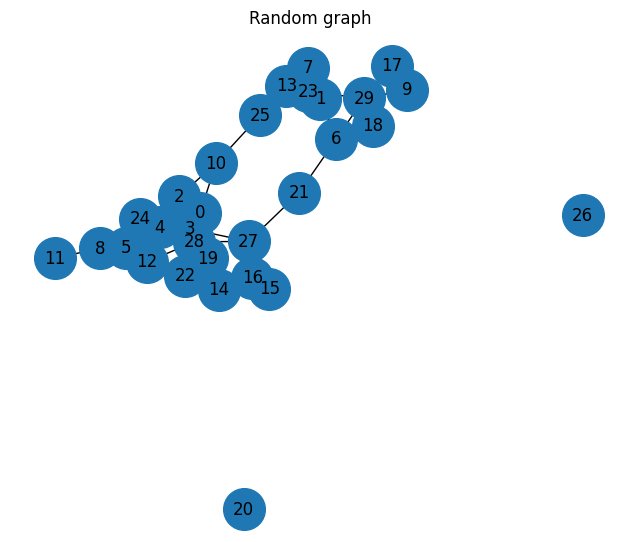

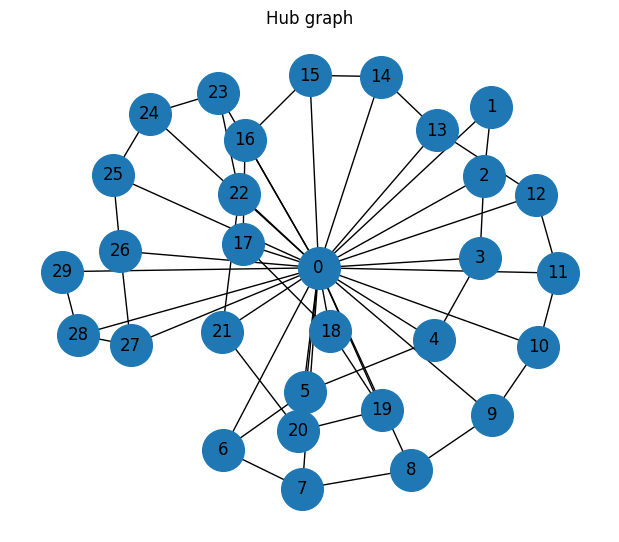

In [15]:
draw_graph(R, "Random graph")
draw_graph(H, "Hub graph")

In [17]:
print(f"Random graph avg. degree: {average_degree(R)}, top deg. seq: {degree_sequence(R)[:10]}")
print(f"Hub graph avg. degree: {average_degree(H)}, top deg. seq: {degree_sequence(H)[:10]}")

Random graph avg. degree: 3.0, top deg. seq: [7, 5, 5, 5, 4, 4, 4, 4, 4, 4]
Hub graph avg. degree: 3.8, top deg. seq: [29, 3, 3, 3, 3, 3, 3, 3, 3, 3]


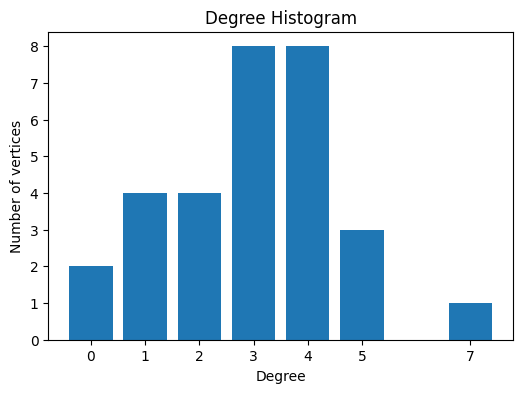

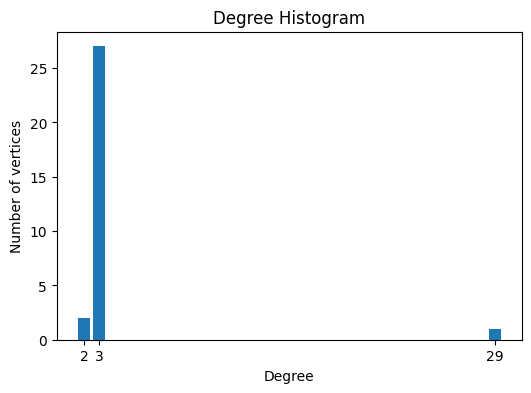

In [18]:
plot_degree_histogram(R)
plot_degree_histogram(H)

Questions:
- Which graph has the more uneven degree distribution?
- Which graph would you expect to be more vulnerable if its highest-degree vertex were removed?
- Which graph has a more obvious hub?
- Does average degree alone distinguish these graphs clearly?

## Part 6: A cumulative view of degree

Instead of asking “how many vertices have degree exactly \(k\)?”, we can ask “how many vertices have degree at most \(k\)?” or “at least \(k\)?”

This gives a cumulative view of the degree distribution (CDF).
At this point, here's where we begin to introduce the tools of statistics into the mix.
By generating distributions and CDFs, building families of (randomly seeded) graphs to benchmark these distributions, and calibrating the statistical distributions of a multitude of global descriptors of the graphs, we can build to doing hypothesis testing.

In [19]:
degree_cdf_data(G)

([2, 2, 3, 3, 3, 3, 3, 3], [0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0])

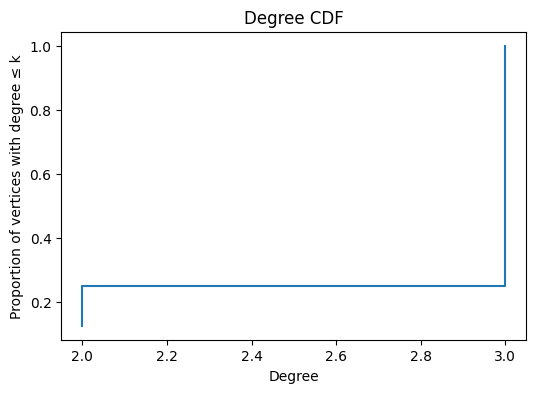

In [20]:
plot_degree_cdf(G)

In [21]:
# TODO: generate some other graphs, compute and plot their CDFs. Try varying the number of nodes and edges.

Questions:
- What does the cumulative view show more clearly than the histogram?
- Does the CDF suggest that degrees are concentrated or spread out?
- How might this help for larger graphs?

## Part 7: A real network example

Now apply the same ideas to Zachary’s Karate Club graph.

In [22]:
K = karate_graph()
graph_summary(K)

{'number_of_nodes': 34,
 'number_of_edges': 78,
 'nodes': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33],
 'edges': [(0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (0, 5),
  (0, 6),
  (0, 7),
  (0, 8),
  (0, 10),
  (0, 11),
  (0, 12),
  (0, 13),
  (0, 17),
  (0, 19),
  (0, 21),
  (0, 31),
  (1, 2),
  (1, 3),
  (1, 7),
  (1, 13),
  (1, 17),
  (1, 19),
  (1, 21),
  (1, 30),
  (2, 3),
  (2, 7),
  (2, 8),
  (2, 9),
  (2, 13),
  (2, 27),
  (2, 28),
  (2, 32),
  (3, 7),
  (3, 12),
  (3, 13),
  (4, 6),
  (4, 10),
  (5, 6),
  (5, 10),
  (5, 16),
  (6, 16),
  (8, 30),
  (8, 32),
  (8, 33),
  (9, 33),
  (13, 33),
  (14, 32),
  (14, 33),
  (15, 32),
  (15, 33),
  (18, 32),
  (18, 33),
  (19, 33),
  (20, 32),
  (20, 33),
  (22, 32),
  (22, 33),
  (23, 25),
  (23, 27),
  (23, 29),
  (23, 32),
  (23, 33),
  (24, 25),
  (24, 27),
  (24, 31),
  (25, 31),
  (26, 29)

In [ ]:
# TODO: compute the global metrics for Zachary's karate club as we did for the random and hub graphs.
# TODO: generate new random and hub graphs with the same number of nodes as Zachary's, and the 
# associated metrics 
# TODO: compare the random and hub metrics to those of Zachary's. Does the real world graph 
# look like either model?

## Part 9: Build your own example

Construct two graphs on the same number of vertices but with very different degree distributions.

Questions:
- Which graph has a more concentrated degree distribution?
- Which graph has a more unequal degree distribution?
- How much can the shape of a graph change while keeping the same number of vertices?